# Setup & mở 3 ảnh lỗi để quan sát

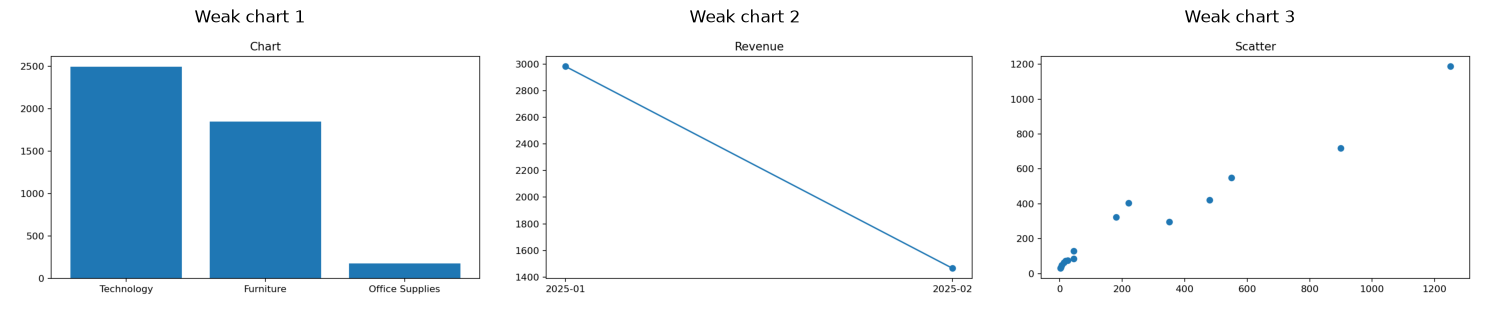

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

df = pd.read_csv("LAB06_09_cleaned_retail_sample.csv")

paths = {
    1: "weak_charts/LAB08_weak_chart_1_vague_title.png",
    2: "weak_charts/LAB08_weak_chart_2_missing_context.png",
    3: "weak_charts/LAB08_weak_chart_3_no_message.png",
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, ax in zip(paths, axes):
    ax.imshow(mpimg.imread(paths[i]))
    ax.axis("off")
    ax.set_title(f"Weak chart {i}")
plt.tight_layout()
plt.show()

#### Weak chart 1 — bar chart tổng revenue theo category:

* Tiêu đề chỉ ghi "Chart" — không nói lên điều gì
* Không có xlabel/ylabel, không có đơn vị (là USD hay gì?)
* Không rõ đây là tổng (sum) hay trung bình (mean) revenue — dễ hiểu nhầm

#### Weak chart 2 — line chart revenue theo tháng (2025-01 → 2025-02):

* Tiêu đề "Revenue" quá chung chung, không nói giảm hay tăng bao nhiêu %
* Không có xlabel ("Month"), không có ylabel/đơn vị
* Trục y không bắt đầu từ 0 (bắt đầu ~1400) → phóng đại trực quan mức độ giảm, đây là lỗi gây hiểu lầm (misleading), không chỉ là "thiếu ngữ cảnh"
* Chỉ có 2 điểm dữ liệu — dễ khiến người xem tưởng đây là xu hướng dài hạn trong khi chỉ là 2 tháng

#### Weak chart 3 — scatter unit_price vs revenue:

* Tiêu đề "Scatter" — đặt tên theo loại biểu đồ, không phải theo message
* Không có nhãn trục/đơn vị
* Không có gì làm nổi bật mối quan hệ tuyến tính rất mạnh giữa 2 biến (đây chính là "no message")

# Tái thiết kế từng biểu đồ

### Chart 1 

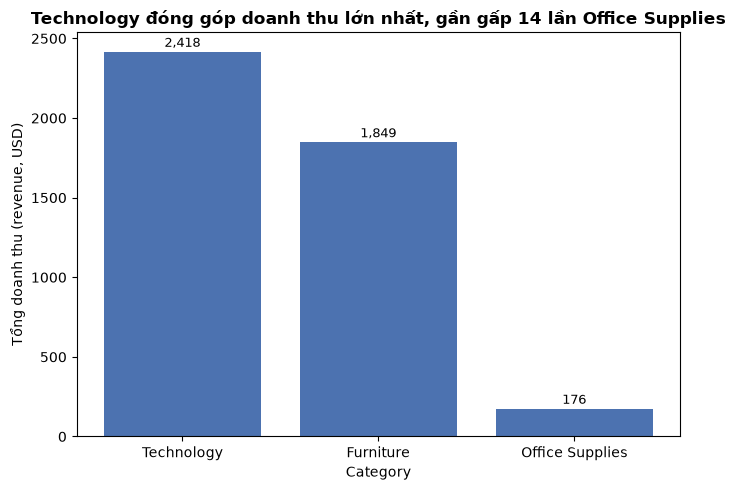

In [2]:
summary = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(summary.index, summary.values, color="#4C72B0")
ax.set_title("Technology đóng góp doanh thu lớn nhất, gần gấp 14 lần Office Supplies",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Tổng doanh thu (revenue, USD)")
for i, v in enumerate(summary.values):
    ax.text(i, v+30, f"{v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("lab08_chart1_after.png", dpi=150)
plt.show()

### Chart 2

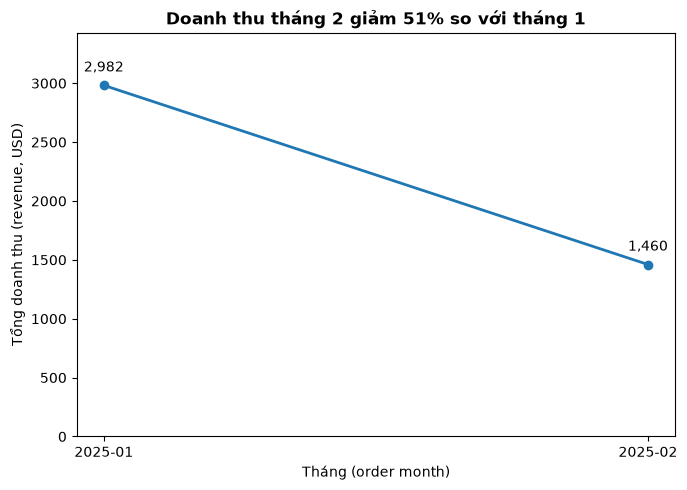

In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])
monthly = df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(monthly.index.astype(str), monthly.values, marker="o", linewidth=2)
ax.set_ylim(0, monthly.max()*1.15)   # bắt đầu từ 0 -> không phóng đại mức giảm
pct_change = (monthly.iloc[-1] - monthly.iloc[0]) / monthly.iloc[0] * 100
ax.set_title(f"Doanh thu tháng 2 giảm {abs(pct_change):.0f}% so với tháng 1",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Tháng (order month)")
ax.set_ylabel("Tổng doanh thu (revenue, USD)")
for x, y in zip(monthly.index.astype(str), monthly.values):
    ax.annotate(f"{y:,.0f}", (x, y), textcoords="offset points", xytext=(0,10), ha="center")
plt.tight_layout()
plt.savefig("lab08_chart2_after.png", dpi=150)
plt.show()

### Chart 3

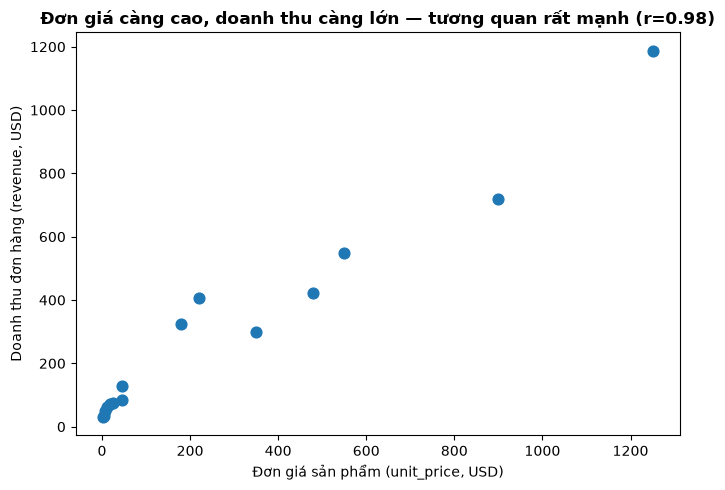

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["unit_price"], df["revenue"], s=60)
corr = df[["unit_price","revenue"]].corr().iloc[0,1]
ax.set_title(f"Đơn giá càng cao, doanh thu càng lớn — tương quan rất mạnh (r={corr:.2f})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Đơn giá sản phẩm (unit_price, USD)")
ax.set_ylabel("Doanh thu đơn hàng (revenue, USD)")
plt.tight_layout()
plt.savefig("lab08_chart3_after.png", dpi=150)
plt.show()

## So sánh trước sau 

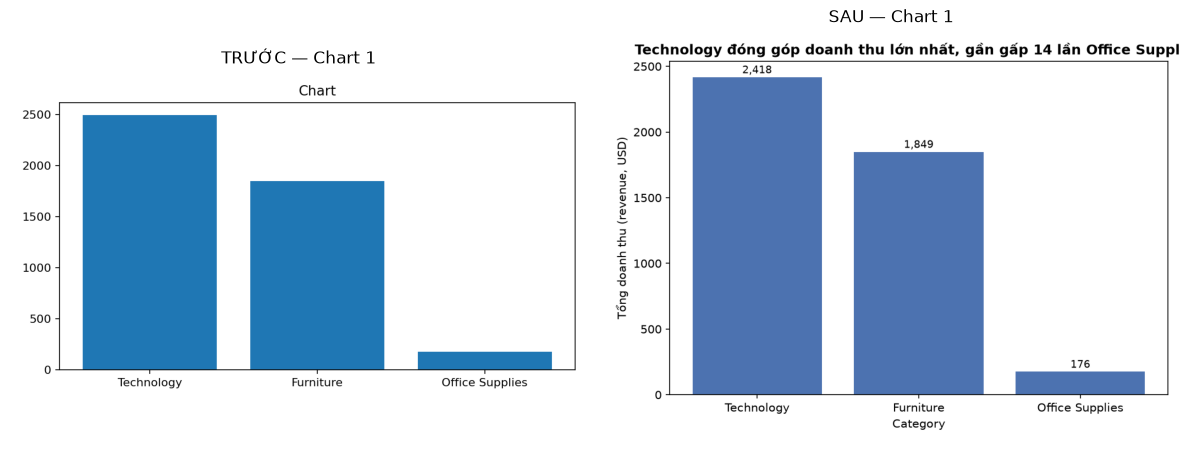

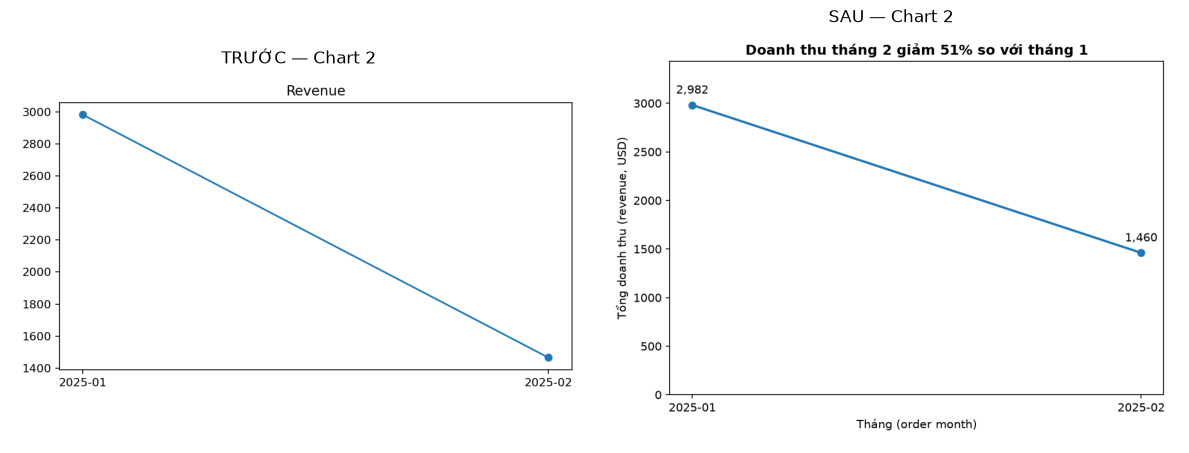

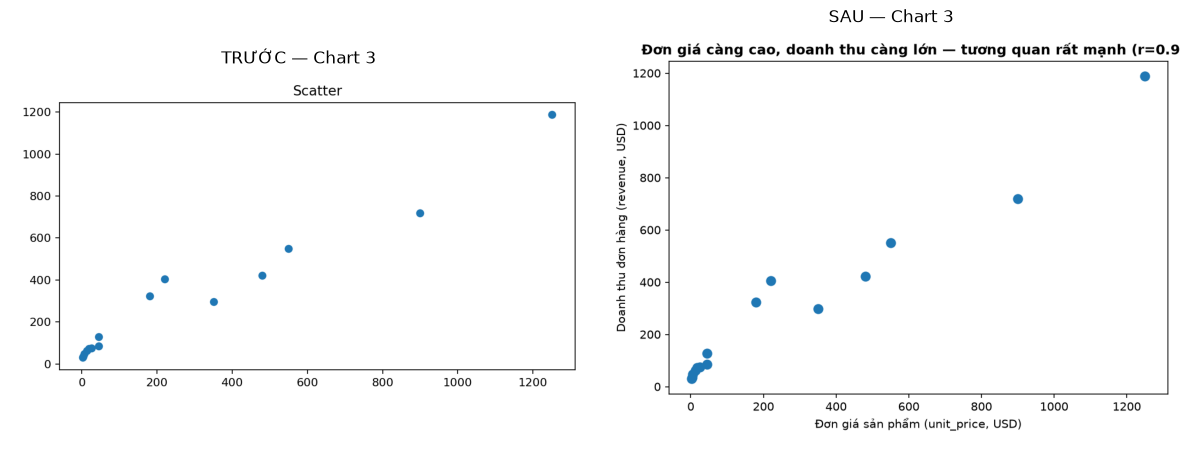

In [5]:
after_paths = {1: "lab08_chart1_after.png", 2: "lab08_chart2_after.png", 3: "lab08_chart3_after.png"}

for i in paths:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].imshow(mpimg.imread(paths[i])); axes[0].axis("off"); axes[0].set_title(f"TRƯỚC — Chart {i}")
    axes[1].imshow(mpimg.imread(after_paths[i])); axes[1].axis("off"); axes[1].set_title(f"SAU — Chart {i}")
    plt.tight_layout()
    plt.show()

| Biểu đồ | Điểm yếu chính | Cải tiến đã thực hiện | Lý do thực hiện | Lợi ích cho người xem |
|---|---|---|---|---|
| Weak chart 1 | Tiêu đề mơ hồ ("Chart"), không có nhãn/đơn vị trục | Đổi tiêu đề thành insight cụ thể, thêm nhãn trục có đơn vị, ghi giá trị lên từng cột | Tiêu đề phải dẫn dắt người đọc hiểu ngay kết luận | Không cần tự tính nhẩm, nắm thông điệp tức thì |
| Weak chart 2 | Thiếu ngữ cảnh trục + trục y bị cắt (không bắt đầu từ 0) gây phóng đại mức giảm | Thêm nhãn/đơn vị trục, chỉnh trục y bắt đầu từ 0, tiêu đề nêu rõ % giảm | Trục bị cắt là lỗi trực quan phổ biến, dễ gây hiểu sai mức độ thay đổi | Người xem đánh giá đúng mức độ giảm thực tế, không bị phóng đại |
| Weak chart 3 | Không có thông điệp ("Scatter" chỉ là tên loại biểu đồ) | Thêm hệ số tương quan vào tiêu đề, nhãn trục có đơn vị | Người xem cần biết mối quan hệ mạnh hay yếu ngay từ tiêu đề | Hiểu ngay mối quan hệ giữa đơn giá và doanh thu mà không cần tự tính r |

Chart 1:

Technology là nhóm mang lại tổng doanh thu cao nhất (~2.4 nghìn USD), gần gấp 14 lần Office Supplies (~175 USD) trong 2 tháng dữ liệu. Furniture đứng thứ hai với ~1.85 nghìn USD. Tuy nhiên tập dữ liệu chỉ có 15 đơn hàng nên khoảng cách này mang tính minh họa, chưa đủ để kết luận xu hướng dài hạn.

Chart 2:

Doanh thu giảm mạnh từ tháng 1 (~2,982 USD) xuống tháng 2 (~1,461 USD), tương đương giảm khoảng 51%. Cần lưu ý đây chỉ là 2 tháng dữ liệu mẫu, chưa đủ để khẳng định xu hướng suy giảm dài hạn hay chỉ là biến động ngẫu nhiên giữa các đơn hàng lớn/nhỏ trong từng tháng.

Chart 3:

Đơn giá sản phẩm và doanh thu đơn hàng có mối tương quan rất mạnh (r ≈ 0.98). Điều này phần lớn đến từ việc revenue được tính trực tiếp từ unit_price × quantity, nên đây là mối quan hệ mang tính công thức hơn là một insight hành vi khách hàng — correlation ở đây không chứng minh quan hệ nhân quả.